In [1]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

from constants import api_key

import time

client = RESTClient(api_key = api_key)

import pyspark
from pyspark.sql.window import Window

import os
import sys

from sklearn.linear_model import LinearRegression, Ridge, Lasso

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [2]:
# spark = (
#     pyspark
#     .sql
#     .SparkSession
#     .builder
#     .appName('sparksession')
#     .config("spark.driver.memory", "8g")
#     .config("spark.executor.memory", "16g")
#     .config("spark.executor.cores", "4")
#     .config("spark.network.timeout", "600s") \
#     .getOrCreate()
# )
# spark.sparkContext.setLogLevel("ERROR")  # Only show errors, suppress warnings and info

In [3]:
ticker = 'I:SPX'
price_performance = collections.defaultdict(list)

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="second", from_="2022-10-16", to="2024-11-01", limit=50000)):
    if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)

ticker_hist = pd.DataFrame(price_performance)

9363636it [03:25, 45550.80it/s]


In [4]:
ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

times = pd.DataFrame(ticker_hist['Time'].unique())
times.columns = ['Time']
times['Time'] = times['Time'].sort_values().reset_index(drop = True)

ab_params = {}

ab_params['a'] = {}
ab_params['b'] = {}


print('analyzing')

dates = ticker_hist['Date'].unique()

for index, date in tqdm(enumerate(dates)):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]

    ticker_hist_date = pd.merge(left = times, right = ticker_hist_date, on = "Time", how = "outer")
    ticker_hist_date = ticker_hist_date.sort_values(by = 'Time').reset_index(drop = True)
    ticker_hist_date = ticker_hist_date.ffill()
    logReturns = ticker_hist_date['logOpen'].diff()[1:]

    #counts, bin_edges = np.histogram(ticker_hist_date['logReturns'], bins=100)
    a = np.median(logReturns)
    b = np.sum(
            np.abs(logReturns - a)
    ) / (len(logReturns))
    ab_params['a'][date] = a
    ab_params['b'][date] = b

analyzing


0it [00:00, ?it/s]/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_62413/3277493712.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ticker_hist_date = ticker_hist_date.ffill()
432it [02:11,  3.29it/s]


In [8]:
ab_params_df = pd.DataFrame(ab_params)
ab_params_df = ab_params_df.dropna()

In [9]:
ab_params_df

,a,b
2023-02-15,0.000000,0.000018
2023-02-16,0.000000,0.000021
2023-02-17,0.000000,0.000019
2023-02-21,0.000000,0.000018
2023-02-22,0.000000,0.000022
...,...,...
2024-10-28,0.000000,0.000013
2024-10-29,0.000000,0.000013
2024-10-30,0.000000,0.000015
2024-10-31,-0.000002,0.000020


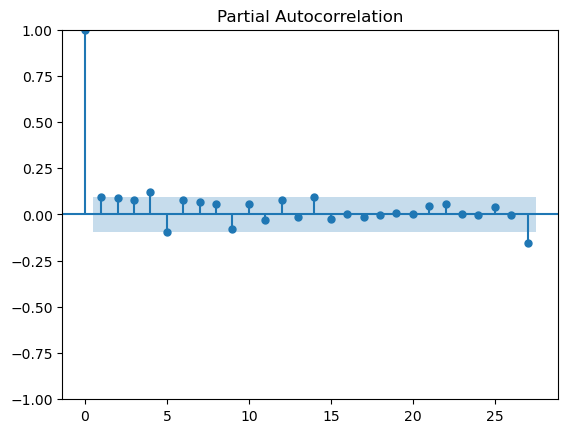

In [10]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['a']
)
plt.show()

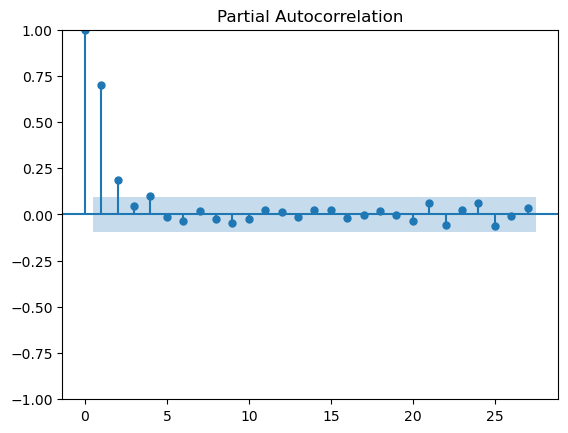

In [11]:
import statsmodels.tsa

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['b']
)
plt.show()

In [12]:
scipy.stats.spearmanr(ab_params_df['a'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

SignificanceResult(statistic=np.float64(0.10374953499099743), pvalue=np.float64(0.03148083479082396))

In [13]:
scipy.stats.pearsonr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['b'].iloc[:-1])

PearsonRResult(statistic=np.float64(0.6999909979266468), pvalue=np.float64(1.4525842992846838e-64))

In [14]:
scipy.stats.spearmanr(ab_params_df['b'].shift(-2).iloc[:-2], ab_params_df['b'].iloc[:-2])

SignificanceResult(statistic=np.float64(0.5423757073181111), pvalue=np.float64(3.5242341960324948e-34))

In [15]:
scipy.stats.spearmanr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

SignificanceResult(statistic=np.float64(0.09489269183718481), pvalue=np.float64(0.0492468562432813))

In [16]:
ab_params_df['shifted_a_1'] = ab_params_df['a'].shift(-1)
ab_params_df['shifted_b_1'] = ab_params_df['b'].shift(-1)



In [17]:
lr_b = LinearRegression()

lr_b.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b_1'])
print(lr_b.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b_1']))

lr_a = LinearRegression()

lr_a.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a_1'])
print(lr_a.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a_1']))


0.49009044179765415
0.08773431984284441


In [18]:
ab_params_df['shifted_a_2'] = ab_params_df['a'].shift(-2)
ab_params_df['shifted_b_2'] = ab_params_df['b'].shift(-2)

In [19]:
r_b = LinearRegression()

r_b.fit(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_b_2'])
print(r_b.score(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_b_2']))

r_a = LinearRegression()

r_a.fit(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_a_2'])
print(r_a.score(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_a_2']))


0.5105112888866732
0.092653902983594


In [20]:
r_b.coef_

array([ 0.62733036,  0.19254786, -0.43062672,  0.56389801])

In [21]:
lr_b.coef_

array([0.13517958, 0.69857447])

In [22]:
lr_a.coef_

array([0.05882988, 0.02141224])

In [23]:
r_a.coef_

array([0.06499192, 0.0028485 , 0.04575593, 0.01905315])

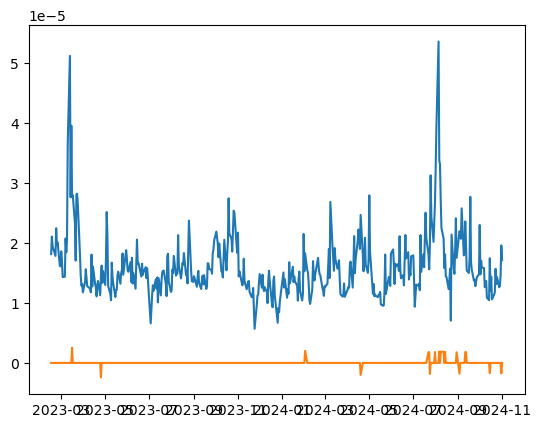

In [24]:
plt.plot(ab_params_df['b'])
plt.plot(ab_params_df['a'])

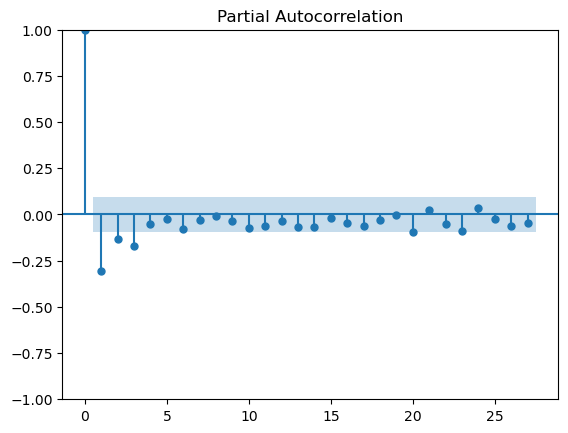

In [25]:
statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['b'].diff()[1:]
)
plt.show()

In [26]:
b_params_df = pd.DataFrame(np.log(ab_params_df['b']))

In [27]:
b_params_df['velo_b'] = b_params_df['b'].diff()

In [28]:
b_params_df['targets'] = b_params_df['b'].shift(-1)

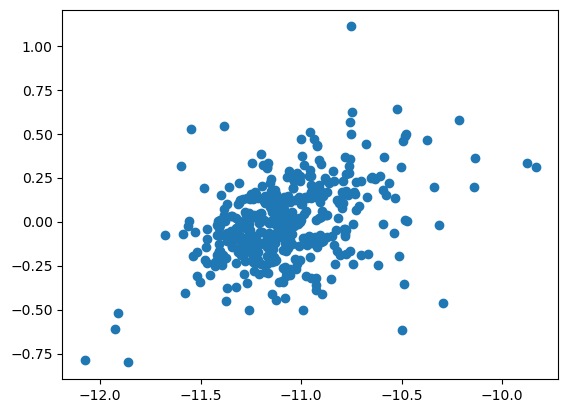

In [29]:
plt.scatter(b_params_df['b'], b_params_df['velo_b'])

In [30]:
scipy.stats.pearsonr(b_params_df.dropna()['b'], b_params_df.dropna()['targets'])

PearsonRResult(statistic=np.float64(0.6783331090932325), pvalue=np.float64(3.9499793850954864e-59))

In [31]:
lr = LinearRegression()

lr.fit(b_params_df.dropna()[['b', 'velo_b']], b_params_df.dropna()['targets'])
print(lr.score(b_params_df.dropna()[['b', 'velo_b']], b_params_df.dropna()['targets']))

0.48022623059325686


In [32]:
replicates = 100000

In [80]:
possible_final_returns = np.zeros(replicates)
for r in tqdm(range(replicates)):
    samples = np.random.laplace(
        loc=r_a.predict(ab_params_df[
            ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1], 
        scale=r_b.predict(
            ab_params_df[
                ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1],
        size=len(ticker_hist_date)
    )

    possible_final_returns[r] = samples.sum()


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [02:18<00:00, 723.97it/s]


In [81]:
len(ticker_hist_date)

23400

In [82]:
6.5*3600

23400.0

In [83]:
np.exp(
    lr.predict(
        b_params_df[
            ['b', 'velo_b']
        ].dropna()
    )[-1]
)

np.float64(1.7118692517632413e-05)

In [84]:
np.std(possible_final_returns)

np.float64(0.003530304738255709)

In [85]:
np.exp(lr.predict(b_params_df[['b', 'velo_b']].dropna())[-1])

np.float64(1.7118692517632413e-05)

# declare spot ticker price

In [86]:
spot_spx_price = 5725.

In [87]:
upper_call = 5770.
lower_call = 5765.
upper_put = 5670.
lower_put = 5665.

In [88]:
possible_final_prices = spot_spx_price * np.exp(np.asarray(possible_final_returns))

In [89]:
print(np.mean(possible_final_prices))
print(np.std(possible_final_prices))

5717.419518825638
20.18457726987835


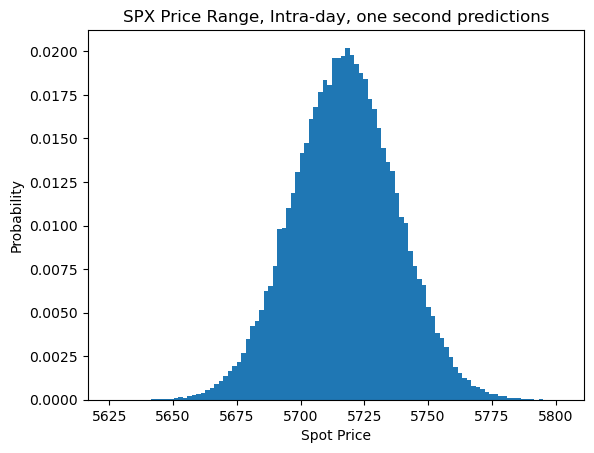

In [90]:
plt.hist(possible_final_prices, bins = 100, density = True)
plt.ylabel('Probability')
plt.xlabel('Spot Price')
plt.title('SPX Price Range, Intra-day, one second predictions')
plt.savefig('end_price_distro_t2.pdf', bbox_inches = 'tight')
plt.show()

In [91]:
payouts = np.zeros(replicates)
for index, price in enumerate(possible_final_prices):
    payout = (
        np.max([0., lower_put - price])
        - np.max([0., upper_put - price])
        - np.max([0., price - lower_call])
        + np.max([0., price - upper_call])
    )

    payouts[index] = payout

Text(0.5, 1.0, 'avg payout is -0.07')

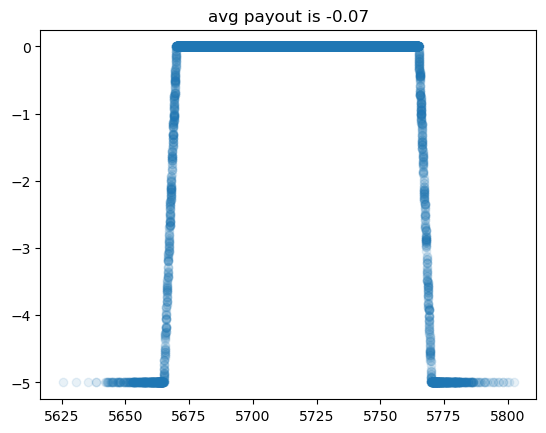

In [92]:
plt.scatter(possible_final_prices, payouts, alpha=0.1)
mean_payout = np.round(np.mean(payouts), 2)
plt.title(f'avg payout is {mean_payout}')

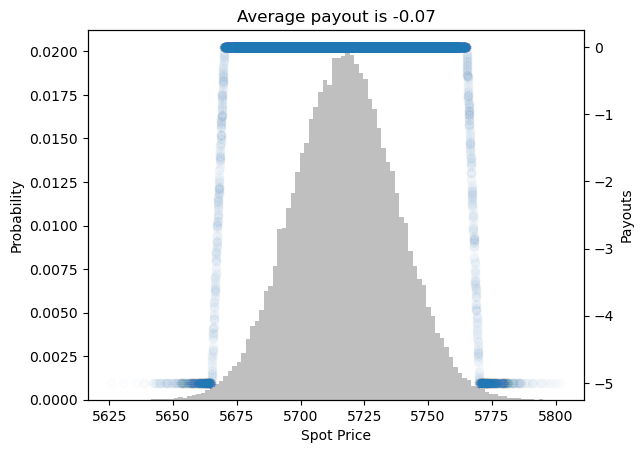

In [93]:
fig, axs = plt.subplots()

axs.hist(possible_final_prices, bins = 100, density = True, alpha=0.5, color = 'grey')
axs.set_ylabel('Probability')
axs.set_xlabel('Spot Price')
#axs.set_title('SPX Price Range, Intra-day, one second predictions')
axs_right = axs.twinx()
#plt.savefig('end_price_distro.pdf', bbox_inches = 'tight')
axs_right.scatter(possible_final_prices, payouts,  alpha=0.01)
axs_right.set_ylabel('Payouts')
mean_payout = np.round(np.mean(payouts), 2)
axs.set_title(f'Average payout is {mean_payout}')
plt.savefig('with_strategy.png', bbox_inches = 'tight')

plt.show()

# compute cost of trade and max loss

In [52]:
cost_of_trade = 1.1
max_loss = 5

In [53]:
p = (max_loss - cost_of_trade)/max_loss

In [54]:
fstar = p - (1-p)/(cost_of_trade/(max_loss-cost_of_trade))
print(f'Kelly Criterion prediction, assuming fair odds, is {fstar}')

Kelly Criterion prediction, assuming fair odds, is 2.220446049250313e-16


In [55]:
my_p = sum(payouts > -cost_of_trade)/len(payouts)

fstar_me = my_p - (1 - my_p)/(cost_of_trade/(max_loss-cost_of_trade))

print(f'Kelly Criterion prediction, assuming my odds, is {fstar_me}')

Kelly Criterion prediction, assuming my odds, is 0.9440454545454544
